In [1]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis.plotting_classes import KdeOffDiagOptions
    from sbi.analysis.plotting_classes import (
        HistDiagOptions,
        HistOffDiagOptions,
        FigOptions,
        ScatterOffDiagOptions,
        ContourOffDiagOptions,
    )
    from sbi.inference import NPE
except ModuleNotFoundError:
    pairplot = None
    KdeOffDiagOptions = None
    HistDiagOptions = None
    HistOffDiagOptions = None
    FigOptions = None
    NPE = None
import os
from astropy.io import fits


2026-06-26 11:25:27.583963: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 11:25:28.462309: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/kn18001/.local/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
os.getcwd()

'/home/cbllover/HalfDome/SBI_analysis'

In [3]:
## Reading in the samples that were generated
samples_Ncluster_P0_alpha_z = np.load(r"outputs/cluster_outputs/16384_no_noise/posterior_samples.npy")

samples_fid_1e5 = np.load("outputs/posteriors/posterior_emulator_N1e5_stop60_cluster_planck_no_noise.npy")

samples_fid_16e3 = np.load("outputs/posteriors/posterior_16e3emul_N4e4_binned16_s42_xo_Planck_synthetic_no_noise.npy")


samples_Ncluster_emul1e5_P0_alpha_z = np.load(r"outputs/cluster_outputs/80k_emul_no_noise/posterior_samples.npy")

In [4]:
theta_true = np.array([18.1, 0.497, 4.35, 0.154, -0.00865,
               0.0393, -0.758,  0.731, 0.415])

n_params = theta_true.shape[0]

param_names = ['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

# -----------------------------
# True / fiducial parameters
# -----------------------------
if isinstance(theta_true, torch.Tensor):
    theta_true_np = theta_true.detach().cpu().numpy()
else:
    theta_true_np = np.asarray(theta_true)

theta_true_np = theta_true_np.reshape(-1)[:n_params]

true_markers = {
    param_names[i]: float(theta_true_np[i])
    for i in range(n_params)
}

In [5]:
theta_true_np

array([ 1.81e+01,  4.97e-01,  4.35e+00,  1.54e-01, -8.65e-03,  3.93e-02,
       -7.58e-01,  7.31e-01,  4.15e-01])

In [58]:
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


In [105]:
import numpy as np
import pandas as pd
import torch

def summarize_posterior(samples, prepared, theta_true=None, display_table=True):
    # Convert samples
    if isinstance(samples, torch.Tensor):
        posterior_np = samples.detach().cpu().numpy()
    else:
        posterior_np = np.asarray(samples)

    if posterior_np.ndim != 2:
        raise ValueError(f"Expected samples shape (n_samples, n_params), got {posterior_np.shape}")

    n_params = posterior_np.shape[1]

    # Parameter names
    param_names = list(prepared.get("param_names", [f"p{i}" for i in range(n_params)]))

    # If samples have fewer params than param_names, truncate names
    param_names = param_names[:n_params]

    if len(param_names) != n_params:
        raise ValueError(
            f"Number of param_names ({len(param_names)}) does not match "
            f"sample dimension ({n_params})"
        )

    # True values
    if theta_true is None:
        theta_true = prepared.get("theta_true", None)

    if theta_true is None:
        true_values = np.full(n_params, np.nan)
    else:
        if isinstance(theta_true, torch.Tensor):
            true_values = theta_true.detach().cpu().numpy()
        else:
            true_values = np.asarray(theta_true)

        true_values = true_values.reshape(-1)

        if len(true_values) >= n_params:
            true_values = true_values[:n_params]
        else:
            raise ValueError(
                f"theta_true has {len(true_values)} values, but samples have {n_params} parameters"
            )

    summary = pd.DataFrame({
        "parameter": param_names,
        "true": true_values,
        "mean": np.mean(posterior_np, axis=0),
        "median": np.median(posterior_np, axis=0),
        "std": np.std(posterior_np, axis=0),
        "q16": np.percentile(posterior_np, 16, axis=0),
        "q84": np.percentile(posterior_np, 84, axis=0),
        "q2.5": np.percentile(posterior_np, 2.5, axis=0),
        "q97.5": np.percentile(posterior_np, 97.5, axis=0),
    })

    summary["median - true"] = summary["median"] - summary["true"]
    summary["mean - true"] = summary["mean"] - summary["true"]
    summary["pull_median"] = summary["median - true"] / summary["std"]
    summary["pull_mean"] = summary["mean - true"] / summary["std"]

    pretty = summary.copy()

    if display_table:
        display(pretty)

    return summary, pretty

In [148]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell


def apply_gaussian_beam_to_cl(cl, fwhm_arcmin=1.6, ells = None):
    """
    Apply Gaussian beam smoothing to an auto-power spectrum.
    """

    ells = np.arange(len(cl))
    print (ells)
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)

    cl_beamed = B_ell**2 * cl

    return cl_beamed, B_ell

def apply_gaussian_beam_to_log10_dl(log10_dl, ells, fwhm_arcmin=1.6):
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)
    log10_dl_beamed = log10_dl + 2.0 * np.log10(B_ell)
    return log10_dl_beamed, B_ell

In [7]:
import numpy as np


PLANCK_TSZ_LMIN = np.asarray(
    [21, 27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 642, 835, 1085],
    dtype=np.float64,
)

PLANCK_TSZ_LMAX = np.asarray(
    [27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 642, 835, 1085, 1411],
    dtype=np.float64,
)

PLANCK_TSZ_ELL_EFF = np.asarray(
    [23.5, 30.5, 40, 52, 68, 89, 117, 152, 198, 257, 335, 436, 567, 738, 959, 1247],
    dtype=np.float32,
)


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)

    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0

    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def make_planck_tsz_table3_binning(ell_values):
    ell_values = np.asarray(ell_values, dtype=np.float64)

    members = []
    for lo, hi in zip(PLANCK_TSZ_LMIN, PLANCK_TSZ_LMAX):
        # Planck bins are edge intervals: lo <= ell < hi.
        idx = np.flatnonzero((ell_values >= lo) & (ell_values < hi))
        if idx.size == 0:
            raise ValueError(f"Empty Planck bin: {lo} <= ell < {hi}")
        members.append(idx.astype(np.int64))

    return {
        "edges": np.asarray([PLANCK_TSZ_LMIN[0], *PLANCK_TSZ_LMAX], dtype=np.float32),
        "members": members,
        "centers": PLANCK_TSZ_ELL_EFF.copy(),
        "counts": np.asarray([idx.size for idx in members], dtype=np.int64),
        "bin_min": np.asarray([ell_values[idx[0]] for idx in members], dtype=np.float32),
        "bin_max": np.asarray([ell_values[idx[-1]] for idx in members], dtype=np.float32),
    }


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    ell_values = np.asarray(ell_values, dtype=np.float64)

    if values.shape[-1] != ell_values.size:
        raise ValueError(f"Last axis has length {values.shape[-1]}, expected {ell_values.size}")

    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]

        if statistic == "mean":
            weights = _bin_weights(ell_values[idx], weighting)
            pieces.append(np.average(selected, axis=-1, weights=weights))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")

    return np.stack(pieces, axis=-1)


def planck_tsz_bin_arrays(ell_unbinned, *arrays, statistic="mean", weighting="uniform"):
    """
    Bin one or more arrays along their last axis using the Planck tSZ 16-bin scheme.

    Each array must have last dimension equal to len(ell_unbinned).
    Works for shapes like:
        (n_ell,)
        (n_samples, n_ell)
        (..., n_ell)
    """
    ell_unbinned = np.asarray(ell_unbinned, dtype=np.float64)
    binning = make_planck_tsz_table3_binning(ell_unbinned)

    binned_arrays = [
        np.ascontiguousarray(
            bin_last_axis(arr, binning, ell_unbinned, statistic=statistic, weighting=weighting),
            dtype=np.float32,
        )
        for arr in arrays
    ]

    ell_binned = np.ascontiguousarray(binning["centers"], dtype=np.float32)

    summary = {
        "n_bins": int(ell_binned.size),
        "ell_eff": ell_binned,
        "bin_edges": binning["edges"],
        "bin_counts": binning["counts"],
        "bin_ell_min": binning["bin_min"],
        "bin_ell_max_included": binning["bin_max"],
        "statistic": statistic,
        "weighting": weighting,
    }

    return ell_binned, *binned_arrays, summary

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def plot_planck_triangle(
    samples_1,
    samples_2,
    n_samples=None,
    true_values=None,
    output_path=None,
    random_seed=42,
    show=True,
    legend_label = []
):
    samples_1_np = to_numpy(samples_1)
    samples_2_np = to_numpy(samples_2)

    n_params = min(samples_1_np.shape[1], samples_2_np.shape[1])

    samples_1_np = samples_1_np[:, :n_params]
    samples_2_np = samples_2_np[:, :n_params]

    if n_samples is not None:
        n_samples = int(n_samples)
        max_available = min(samples_1_np.shape[0], samples_2_np.shape[0])

        if n_samples <= 0:
            raise ValueError("n_samples must be positive")
        if n_samples > max_available:
            raise ValueError(
                f"Requested n_samples={n_samples}, but only {max_available} are available in both chains."
            )

        rng = np.random.default_rng(random_seed)
        idx_1 = rng.choice(samples_1_np.shape[0], size=n_samples, replace=False)
        idx_2 = rng.choice(samples_2_np.shape[0], size=n_samples, replace=False)

        samples_1_np = samples_1_np[idx_1]
        samples_2_np = samples_2_np[idx_2]

    names = [f"p{i}" for i in range(n_params)]

    labels = [
        r"P_0",
        r"x_{\rm c}",
        r"\beta",
        r"\alpha_{m,P_0}",
        r"\alpha_{m,x_{\rm c}}",
        r"\alpha_{m,\beta}",
        r"\alpha_{z,P_0}",
        r"\alpha_{z,x_{\rm c}}",
        r"\alpha_{z,\beta}",
    ][:n_params]

    gd_samples_1 = MCSamples(
        samples=samples_1_np,
        names=names,
        labels=labels,
        label=r"Planck synthetic",
    )

    gd_samples_2 = MCSamples(
        samples=samples_2_np,
        names=names,
        labels=labels,
        label=r"Planck true noise",
    )

    for gd in [gd_samples_1, gd_samples_2]:
        gd.updateSettings({
            "smooth_scale_1D": 0.3,
            "smooth_scale_2D": 0.3,
            "fine_bins": 2048,
            "fine_bins_2D": 1024,
        })

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
    })

    double_col_width_in = 18.0 / 2.54
    g = plots.get_subplot_plotter(width_inch=double_col_width_in)

    g.settings.axes_fontsize = 7
    g.settings.lab_fontsize = 8
    g.settings.legend_fontsize = 8
    g.settings.alpha_filled_add = 0.55
    g.settings.linewidth = 1.0
    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.scaling = False

    plot_kwargs = {}

    if true_values is not None:
        plot_kwargs["markers"] = to_numpy(true_values)[:n_params]
        plot_kwargs["marker_args"] = {
            "color": "black",
            "lw": 0.8,
            "ls": "--",
        }

    g.triangle_plot(
        [gd_samples_1, gd_samples_2],
        params=names,
        filled=True,
        legend_labels=[
            legend_label[0],
            legend_label[1],
        ],
        contour_lws=[0.9, 0.9],
        diag1d_kwargs={"linewidth": 1.0},
        **plot_kwargs,
    )

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    if show:
        plt.show()

    return g, gd_samples_1, gd_samples_2

Removed no burn in
Removed no burn in


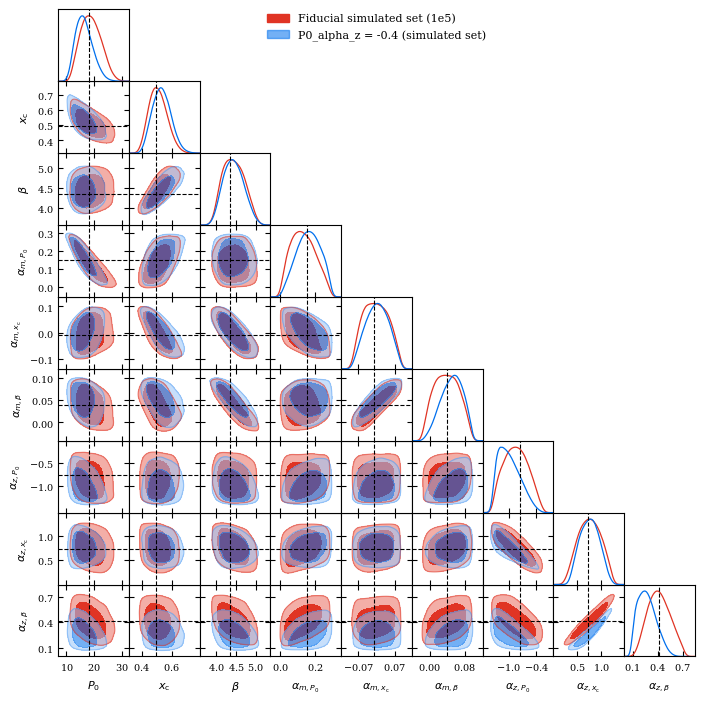

(<getdist.plots.GetDistPlotter at 0x756f37a6a810>,
 <getdist.mcsamples.MCSamples at 0x756f37ba2c10>)

In [19]:
plot_planck_triangle(
    samples_fid_1e5,
    samples_Ncluster_emul1e5_P0_alpha_z,
    n_samples=40000,
    true_values=theta_true_np,
    legend_label = ["Fiducial simulated set (1e5)", "P0_alpha_z = -0.4 (simulated set)"],
    output_path="../plots/SBI_plots/P0_alpha_z_variation_for_simulated_set_no_noise.jpg"
)

# Getting samples from posterior

In [9]:
import sbi, torch, sys
print(sys.executable)
print("sbi:", sbi.__version__)
print("torch:", torch.__version__)

/home/cbllover/miniconda3/bin/python
sbi: 0.22.0
torch: 2.8.0+cu128


In [ ]:
# !{sys.executable} -m pip install torch==2.4.1

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/797.1 MB 16.0 MB/s eta 0:00:40

In [10]:
import pickle
posterior_object_path = Path(r"outputs/cluster_outputs/80k_emul_no_noise/posterior_samples.pkl")

with posterior_object_path.open("rb") as handle:
    posterior = pickle.load(handle)

In [11]:
def Dl_from_fits(fname):
    with fits.open(fname) as hdul:
        hdul.info()
        data = hdul[1].data if len(hdul) > 1 else hdul[0].data
        print(data.names if hasattr(data, "names") else "image array")

    C_l_P0 = data["C_l"]
    cl = data["C_l"]
    lmax = 3*cl.shape[0] - 1
    ell = np.arange(len(cl))

    Dl_P0 = ell*(ell+1)*cl/(2*np.pi)
    return ell, Dl_P0

# Load the other x_obs where one of the parameter is varied

In [12]:
#### P0 amp

x_obs_P0_amp_path = "../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_P0_alpha_z_m0p4_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits" 

ell, Dl_P0 = Dl_from_fits(x_obs_P0_amp_path)

Dl_P0_GB, _ = apply_gaussian_beam_to_cl(Dl_P0, fwhm_arcmin=10)

ell_obs_binned, Dl_obs_binned, binning_summary = planck_tsz_bin_arrays(
    ell[2:],
    np.log10(Dl_P0_GB[2:]),
)

Filename: ../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_P0_alpha_z_m0p4_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Cl            1 BinTableHDU     13   4097R x 2C   [1I, 1D]   
['Index', 'C_l']


In [96]:
### x_c_ alpha
x_obs_x_c_alpha_m_path = "../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_x_c_alpha_m_0p004_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits" 

ell, Dl_x_c_alpha_m = Dl_from_fits(x_obs_x_c_alpha_m_path)

Dl_x_c_alpha_m_GB, _ = apply_gaussian_beam_to_cl(Dl_x_c_alpha_m, fwhm_arcmin=10)

ell_obs_binned, Dl_obs_x_c_alpha_m, binning_summary = planck_tsz_bin_arrays(
    ell[2:],
    np.log10(Dl_x_c_alpha_m_GB[2:]),
)

Filename: ../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_x_c_alpha_m_0p004_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Cl            1 BinTableHDU     13   4097R x 2C   [1I, 1D]   
['Index', 'C_l']
[   0    1    2 ... 4094 4095 4096]


In [100]:
### x_c_ alpha
x_obs_x_c_amp_path = "../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_x_c_amp_0p4_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits" 

ell, Dl_x_c_amp = Dl_from_fits(x_obs_x_c_amp_path)

Dl_x_c_amp_GB, _ = apply_gaussian_beam_to_cl(Dl_x_c_amp, fwhm_arcmin=10)

ell_obs_binned, Dl_obs_x_c_amp, binning_summary = planck_tsz_bin_arrays(
    ell[2:],
    np.log10(Dl_x_c_amp_GB[2:]),
)

Filename: ../tSZ_visuals/tSZ_visuals/full_map_outputs/halfdome_tSZ_cl_m200c_base_plus_battaglia_x_c_amp_0p4_cosmo_fid_nside4096_gaussbeam_1p6arcmin_fullmap_finalonly_lmax4096.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Cl            1 BinTableHDU     13   4097R x 2C   [1I, 1D]   
['Index', 'C_l']
[   0    1    2 ... 4094 4095 4096]


In [13]:
fid_NFW_path = "../HPC_output/HalfDome/tSZ_HalfDome_fiducial_nside4096_cluster.npy"

Dl_fid = np.load(fid_NFW_path)

Dl_fid_GB, _ = apply_gaussian_beam_to_cl(Dl_fid, fwhm_arcmin=10)

ell_obs_binned, Dl_fid_GB_bin, binning_summary = planck_tsz_bin_arrays(
    ell[2:],
    np.log10(Dl_fid_GB[2:]),
)


## emulator generation

In [161]:
import joblib

artifact_path = "../emulator_tSZ/outputs/binned_16e3_16/binned_tsz_emulator16e3_bin16.joblib"
out_path = "wanted_tsz_profile.csv"

params = {
    "P0": 18.1,
    "xc": 0.4,
    "beta": 4.35,
    "alpha_m_P0": 0.154,
    "alpha_m_xc": -0.00865,
    "alpha_m_beta": 0.0393,
    "alpha_z_P0": -0.758,
    "alpha_z_xc": 0.731,
    "alpha_z_beta": 0.415,
}

artifact = joblib.load(artifact_path)
cols = artifact.get("theta_columns", artifact["x_columns"])
theta = np.array([[params[c] for c in cols]], dtype=np.float32)

model = artifact["model"]
theta_s = model.named_steps["x_scaler"].transform(theta)
z_pred = model.named_steps["regressor"].predict(theta_s)
profile = model.named_steps["pca"].inverse_transform(z_pred)[0]

ell = np.asarray(artifact["ell"], dtype=float)
# np.savetxt(
#     out_path,
#     np.column_stack([ell, profile]),
#     delimiter=",",
#     header="ell,log10_D_ell",
#     comments="",
# )
print("parameter order:", cols)
print("wrote", out_path)

Dl_xc_amp_binned_em, _ = apply_gaussian_beam_to_log10_dl(profile,ell, fwhm_arcmin=10)

parameter order: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
wrote wanted_tsz_profile.csv


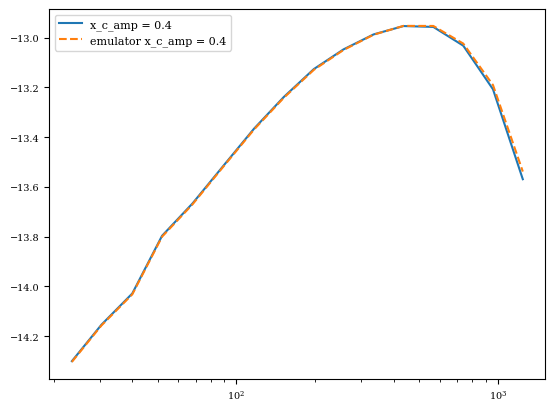

In [163]:
# plt.plot(ell[2:], np.log10(Dl_P0_GB[2:]))


# plt.plot(ell_obs_binned, Dl_obs_binned, label = 'P0 = 20')
# plt.plot(ell_obs_binned, Dl_fid_GB_bin, label = "fid")
plt.plot(ell_obs_binned, Dl_obs_x_c_amp, label = "x_c_amp = 0.4")
plt.plot(ell, Dl_xc_amp_binned_em, "--", label= "emulator x_c_amp = 0.4")


plt.xscale("log")
# plt.yscale("log")
plt.legend()

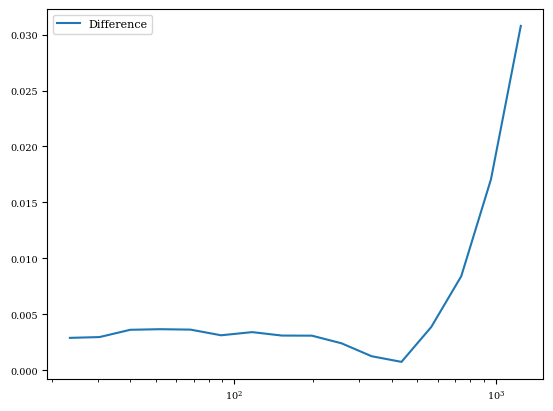

In [158]:
plt.plot(ell_obs_binned, abs(Dl_xc_amp_binned_em - Dl_obs_x_c_amp), label = "Difference")


plt.xscale("log")
# plt.yscale("log")
plt.legend()

In [15]:
ell_obs_binned

array([  23.5,   30.5,   40. ,   52. ,   68. ,   89. ,  117. ,  152. ,
        198. ,  257. ,  335. ,  436. ,  567. ,  738. ,  959. , 1247. ],
      dtype=float32)

In [16]:
scale = 1.3813351099973066
log_scale = np.float32(np.log10(scale))

In [17]:
samples_fid = posterior.sample((100000,), x=Dl_fid_GB_bin+ log_scale)


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

In [19]:
samples_P0 = posterior.sample((100000,), x=Dl_obs_binned+ log_scale)


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

In [97]:
samples_xc_alpha_m = posterior.sample((100000,), x=Dl_obs_x_c_alpha_m+ log_scale)

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

In [101]:
samples_xc_amp = posterior.sample((100000,), x=Dl_obs_x_c_amp+ log_scale)

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

In [153]:
samples_xc_amp_em = posterior.sample((100000,), x=Dl_xc_amp_binned_em + log_scale)

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

Removed no burn in
Removed no burn in


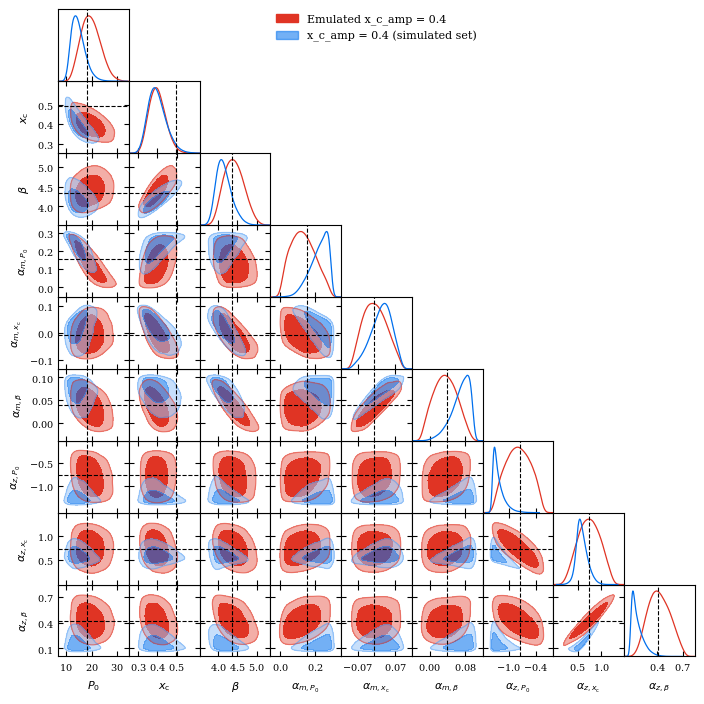

(<getdist.plots.GetDistPlotter at 0x733948f3cbd0>,
 <getdist.mcsamples.MCSamples at 0x733948f49bd0>)

In [154]:
plot_planck_triangle(
#     samples_fid,
    samples_xc_amp_em,
    samples_xc_amp,
    n_samples=50000,
    true_values=theta_true_np,
    legend_label = ["Emulated x_c_amp = 0.4", "x_c_amp = 0.4 (simulated set)"],
#     output_path="../plots/SBI_plots/P0_amp_variation_for_simulated_set_no_noise.jpg"
)


In [108]:
summary, pretty = summarize_posterior(samples_xc_amp, {"param_names" : param_names},
                                      theta_true=np.array([18.1, 0.4, 4.35, 0.154, -0.00865,
               0.0393, -0.758,  0.731, 0.415]))

,parameter,true,mean,median,std,q16,q84,q2.5,q97.5,median - true,mean - true,pull_median,pull_mean
0,P0,18.10000,14.826411,14.433414,2.774089,12.166043,17.507424,10.587907,21.249514,-3.666586,-3.273589,-1.321726,-1.180059
1,xc,0.40000,0.399145,0.394494,0.047857,0.352209,0.446034,0.319272,0.505217,-0.005506,-0.000855,-0.115058,-0.017858
2,beta,4.35000,4.154122,4.131485,0.202734,3.957504,4.355039,3.820058,4.612771,-0.218515,-0.195878,-1.077840,-0.966182
3,alpha_m_P0,0.15400,0.220314,0.229560,0.051329,0.165971,0.272771,0.103295,0.289096,0.075560,0.066314,1.472069,1.291950
4,alpha_m_xc,-0.00865,0.017736,0.021331,0.039952,-0.023830,0.057852,-0.068583,0.086992,0.029981,0.026386,0.750423,0.660443
5,alpha_m_beta,0.03930,0.069568,0.073470,0.021121,0.048090,0.090682,0.019160,0.098137,0.034170,0.030268,1.617831,1.433099
6,alpha_z_P0,-0.75800,-1.226679,-1.264517,0.128351,-1.337325,-1.114041,-1.359648,-0.881583,-0.506517,-0.468679,-3.946345,-3.651542
7,alpha_z_xc,0.73100,0.592015,0.577197,0.119869,0.483915,0.708776,0.381851,0.862058,-0.153803,-0.138985,-1.283091,-1.159471
8,alpha_z_beta,0.41500,0.163798,0.144052,0.070503,0.099320,0.231843,0.086128,0.344134,-0.270948,-0.251202,-3.843064,-3.562980


In [107]:
theta_true

tensor([[20.2418,  0.8052,  4.9237,  ..., -0.3772,  0.4057,  0.1077],
        [20.2527,  0.5577,  4.4381,  ..., -1.2277,  0.1669,  0.2246],
        [ 2.3528,  0.1614,  4.7442,  ..., -0.8683,  0.2378,  0.6978],
        ...,
        [ 6.9582,  0.7713,  3.9832,  ..., -0.8545,  0.2467,  0.4106],
        [21.4138,  0.8231,  4.3031,  ..., -0.3742,  0.7042,  0.5436],
        [24.8669,  0.3158,  5.0526,  ..., -1.3411,  1.1266,  0.3261]])

# SBC tests

In [24]:
from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, selected_ell_mask
import json
def npz_scalar_to_str(data, key, default=""):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    if value.size == 1:
        return str(value.reshape(-1)[0])
    return default


def npz_json_dict(data, key):
    raw = npz_scalar_to_str(data, key, default="")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def masked_2d_array(data, key, mask):
    values = np.asarray(data[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{key} must be 2D, got shape {values.shape}")
    if values.shape[1] != mask.size:
        raise ValueError(f"{key} has {values.shape[1]} ell columns, expected {mask.size}")
    return values[:, mask]


def load_generated_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing SBI dataset: {path}\\n"
            "Generate it from emulator_tSZ/train_binned_tSZ_emulator.ipynb first, "
            "or uncomment the original 4096-profile DATA_PATH block above."
        )

    with np.load(path, allow_pickle=True) as data:
        if "theta" not in data.files or "ell" not in data.files:
            raise KeyError(f"{path} must contain at least theta and ell")
        if "theta_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["theta_columns"]).tolist()]
        elif "x_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["x_columns"]).tolist()]
        else:
            raise KeyError(f"{path} is missing theta_columns or x_columns")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        target_kind = npz_scalar_to_str(data, "target_kind", default="")
        binning_config = npz_json_dict(data, "binning_json")

        direct_key = None
        for candidate in ("x_log10_dl", "x_binned"):
            if candidate in data.files:
                direct_key = candidate
                break
        if direct_key is None and "x" in data.files:
            x_candidate = np.asarray(data["x"])
            if x_candidate.ndim == 2 and x_candidate.shape[1] == ell_all.size:
                target_lower = target_kind.lower()
                if "log10" in target_lower or "binned" in target_lower:
                    direct_key = "x"

        x_combined = None
        x_lightcones = {}
        cl_mean = None
        cl_keys = []
        data_vector_label = ""
        if direct_key is not None:
            x_combined = masked_2d_array(data, direct_key, mask)
            data_vector_label = f"{direct_key} ({target_kind or 'log10(D_l)'})"
        else:
            cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
            spectra = {
                key: masked_2d_array(data, key, mask)
                for key in cl_keys
            }

            if spectra:
                shapes = {values.shape for values in spectra.values()}
                if len(shapes) != 1:
                    raise ValueError(f"Spectrum arrays have inconsistent shapes: {shapes}")
                if len(spectra) == 1:
                    cl_mean = next(iter(spectra.values()))
                else:
                    cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
            elif "cl_stack" in data.files:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)
                if cl_stack.ndim != 3:
                    raise ValueError(f"Expected cl_stack with shape (n, n_lightcones, ell), got {cl_stack.shape}")
                cl_stack = cl_stack[:, :, mask]
                if cl_stack.shape[1] == 0:
                    raise ValueError(f"{path} contains an empty cl_stack")
                cl_mean = np.mean(cl_stack, axis=1)
            elif "cl_mean" in data.files:
                cl_mean = masked_2d_array(data, "cl_mean", mask)
            else:
                raise KeyError(f"{path} has no x_log10_dl/x_binned/x or C_l arrays matching cl_y*, cl_stack, or cl_mean")
            data_vector_label = "C_l converted to log10(D_l)"

        dataset = {
            "theta": np.asarray(data["theta"], dtype=float),
            "theta_columns": theta_columns,
            "ell": ell_all[mask],
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "x_combined": x_combined,
            "x_lightcones": x_lightcones,
            "source_path": str(path),
            "target_kind": target_kind,
            "data_vector_label": data_vector_label,
            "binning_config": binning_config,
            "is_prebinned": bool(direct_key is not None and ("binned" in target_kind.lower() or "bin_counts" in data.files or direct_key == "x_binned")),
        }

        for key in ("bin_counts", "bin_ell_min", "bin_ell_max"):
            if key in data.files:
                values = np.asarray(data[key])
                if values.ndim == 1 and values.shape[0] == ell_all.size:
                    values = values[mask]
                dataset[key] = values

        for key in cl_keys:
            dataset[key] = masked_2d_array(data, key, mask)

    n_rows = dataset["theta"].shape[0]
    data_rows = dataset["x_combined"].shape[0] if dataset["x_combined"] is not None else dataset["cl_mean"].shape[0]
    if n_rows != data_rows:
        raise ValueError("theta rows and spectrum rows do not match")
    if n_rows == 0:
        raise ValueError("Dataset contains no parameter rows")

    if n_rows <= 50_000:
        duplicate_count = n_rows - np.unique(dataset["theta"], axis=0).shape[0]
        if duplicate_count:
            raise ValueError(f"Found {duplicate_count} duplicate parameter rows in {path}")
    else:
        print(f"Skipping exact duplicate-row check for {n_rows} rows.")

    return dataset

EMULATOR_SBI_DATA_PATH =  "../emulator_tSZ/outputs/binned_16e3_16/sbi16e3_bin16_dataset_100_000.npz"
dataset = load_generated_sbi_dataset(EMULATOR_SBI_DATA_PATH)
param_names = list(dataset["theta_columns"])

Skipping exact duplicate-row check for 100000 rows.


In [88]:
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393, 1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)

In [27]:
dataset_dl = dataset["x_combined"][80000:]
dataset_theta = dataset["theta"][80000:]

In [64]:
# iterating through thousand exmaples
dict_SBI = {}
for i in range(1000):
    dataset_sample = dataset_dl[i]
    dataset_theta_sample = dataset_theta[i]
    
    Dl_example_GB = apply_gaussian_beam_to_log10_dl(dataset_sample, ell_obs_binned, fwhm_arcmin=10)
    samples_temp = posterior.sample((40000,), x=Dl_example_GB + log_scale)
        
    mean_temp = np.mean(np.asarray(samples_temp), axis=0)
    
    dict_SBI[i] = [dataset_theta_sample, mean_temp]


Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

...

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

Drawing 40000 posterior samples:   0%|          | 0/40000 [00:00<?, ?it/s]

In [65]:
posterior_samples = []
for i in range(1000):
    posterior_samples.append(dict_SBI[i][1])

In [92]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

def to_tensor(x, device=None):
    if hasattr(x, "detach"):
        out = x.detach().float()
    else:
        out = torch.as_tensor(x, dtype=torch.float32)
    if device is not None:
        out = out.to(device)
    return out


def percent_diff_from_prior(value, prior_mean):
    """
    Signed percentage difference relative to prior mean.
    Returns NaN if prior_mean is zero (to avoid division by zero).
    """
    if np.isclose(prior_mean, 0.0):
        return np.nan
    return 100.0 * (value - prior_mean) / abs(prior_mean)


def plot_true_vs_posterior_mean(
    posterior_mean,
    theta_true,
    labels,
    prior_low,
    prior_high,
    max_cols=3,
):
    posterior_mean = to_tensor(posterior_mean)
    theta_true = to_tensor(theta_true)
    prior_low = to_tensor(prior_low).reshape(-1)
    prior_high = to_tensor(prior_high).reshape(-1)

    if posterior_mean.ndim != 2:
        raise ValueError(f"posterior_mean must be 2D, got {posterior_mean.shape}")
    if theta_true.ndim != 2:
        raise ValueError(f"theta_true must be 2D, got {theta_true.shape}")
    if posterior_mean.shape != theta_true.shape:
        raise ValueError(
            f"Shape mismatch: posterior_mean {posterior_mean.shape}, "
            f"theta_true {theta_true.shape}"
        )

    n_cases, n_params = theta_true.shape
    labels = list(labels)[:n_params]
    prior_low = prior_low[:n_params]
    prior_high = prior_high[:n_params]
    prior_mean = 0.5 * (prior_low + prior_high)

    ncols = min(max_cols, n_params)
    nrows = int(math.ceil(n_params / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.2 * ncols, 3.6 * nrows),
        squeeze=False
    )
    axes_flat = axes.ravel()

    rows = []

    for j, name in enumerate(labels):
        ax = axes_flat[j]

        x = theta_true[:, j].cpu().numpy()
        y = posterior_mean[:, j].cpu().numpy()
        pm = float(prior_mean[j].cpu().numpy())

        true_mean_j = float(np.mean(x))
        post_mean_j = float(np.mean(y))

        lo = min(np.min(x), np.min(y), pm, true_mean_j, post_mean_j)
        hi = max(np.max(x), np.max(y), pm, true_mean_j, post_mean_j)
        pad = 0.04 * (hi - lo) if hi > lo else 1.0
        lo -= pad
        hi += pad

        # scatter
        ax.scatter(
            x, y,
            s=16,
            alpha=0.65,
            edgecolor="none",
            label="validation cases" if j == 0 else None,
        )

        # perfect recovery
        ax.plot(
            [lo, hi], [lo, hi],
            color="black", ls="--", lw=1.2,
            label="perfect recovery" if j == 0 else None,
        )

        # prior mean lines
        ax.axvline(
            pm, color="gray", ls=":", lw=1.1,
            label="prior mean" if j == 0 else None,
        )
        ax.axhline(pm, color="gray", ls=":", lw=1.1)

        # true mean line (x-axis quantity)
        ax.axvline(
            true_mean_j,
            color="blue",
            ls="--",
            lw=1.1,
            label="true mean" if j == 0 else None,
        )

        # posterior mean mean line (y-axis quantity)
        ax.axhline(
            post_mean_j,
            color="red",
            ls="--",
            lw=1.1,
            label="posterior mean mean" if j == 0 else None,
        )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(name)
        ax.set_xlabel("true")
        ax.set_ylabel("posterior mean")

        rows.append({
            "parameter": name,
            "prior_mean": pm,
            "true_mean": true_mean_j,
            "posterior_mean_mean": post_mean_j,
            "% diff true vs prior": percent_diff_from_prior(true_mean_j, pm),
            "% diff posterior_mean vs prior": percent_diff_from_prior(post_mean_j, pm),
        })

    for ax in axes_flat[n_params:]:
        ax.axis("off")

    axes_flat[0].legend(frameon=False, fontsize=8)
    fig.suptitle("True value vs posterior mean", y=1.02)
    fig.tight_layout()

    return fig, axes, pd.DataFrame(rows)

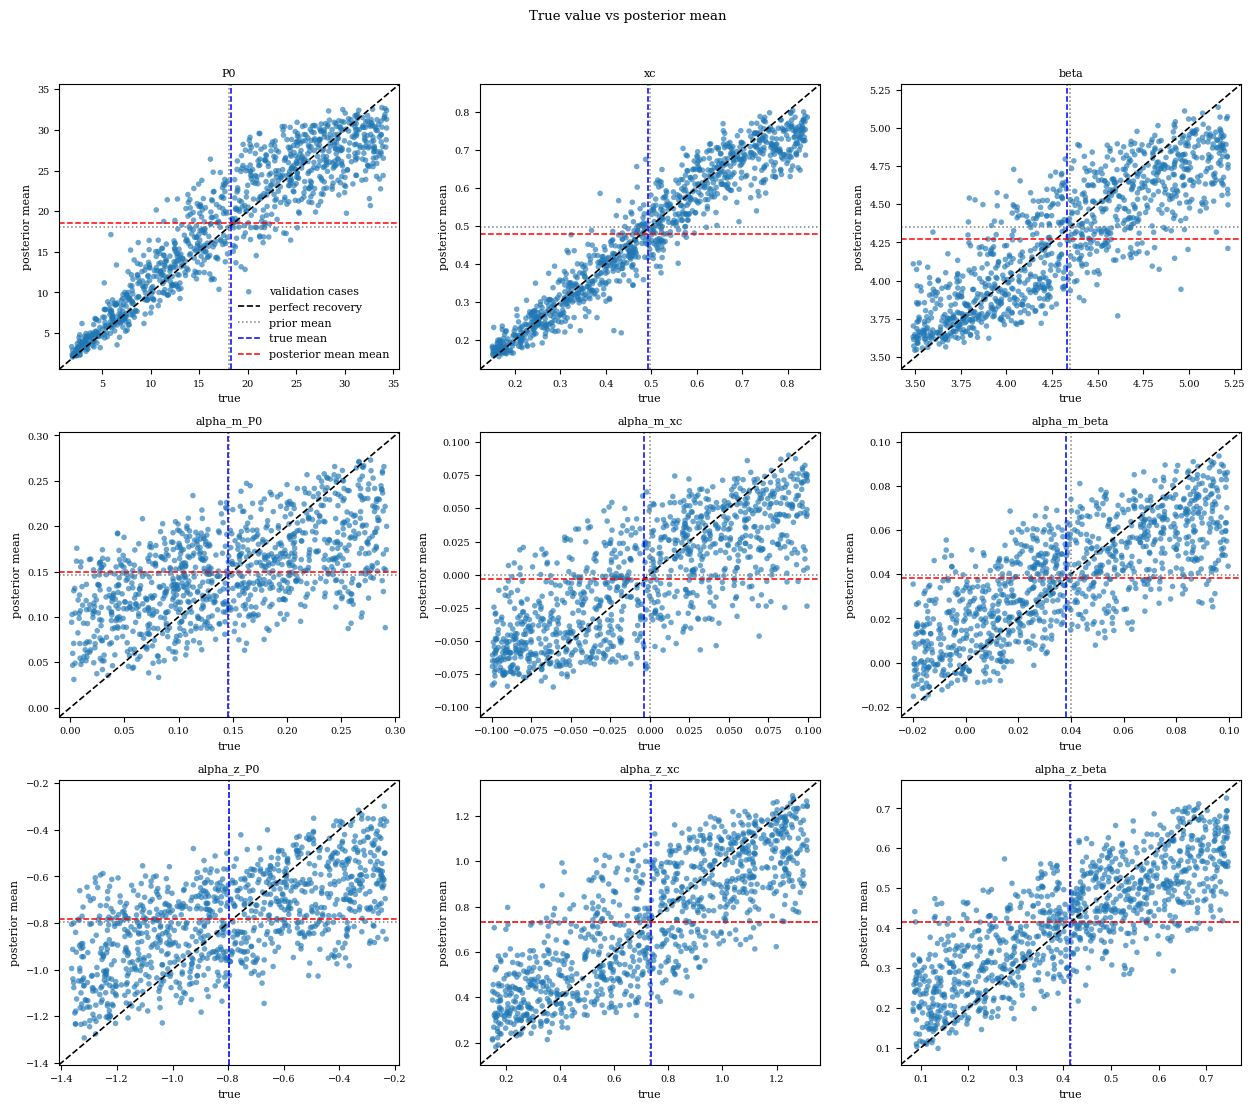

,parameter,prior_mean,true_mean,posterior_mean_mean,% diff true vs prior,% diff posterior_mean vs prior
0,P0,18.086872,18.264290,18.563540,0.980920,2.635433
1,xc,0.497257,0.493916,0.478850,-0.671920,-3.701723
2,beta,4.348619,4.330321,4.275844,-0.420770,-1.673517
3,alpha_m_P0,0.146281,0.145543,0.149201,-0.504738,1.996132
4,alpha_m_xc,0.000039,-0.003457,-0.003053,-9077.773948,-8029.732100
5,alpha_m_beta,0.039916,0.038291,0.038351,-4.070558,-3.919684
6,alpha_z_P0,-0.796148,-0.796669,-0.781977,-0.065486,1.779961
7,alpha_z_xc,0.730933,0.734371,0.734441,0.470300,0.479906
8,alpha_z_beta,0.414846,0.412755,0.414995,-0.504112,0.035869


In [93]:
fig, axes, true_vs_mean_df = plot_true_vs_posterior_mean(
    posterior_samples,          # actually posterior means, shape (1000, 9)
    dataset_theta[:1000],              # true values, shape (1000, 9)
    param_names,
    prior_low=prior_low_np,
    prior_high=prior_high_np,
)

plt.show()
display(true_vs_mean_df)

In [82]:
print ("posterior_samples: ",np.array(posterior_samples).shape)
print ("dataset_theta: ",dataset_theta[:1000].shape)

posterior_samples:  (1000, 9)
dataset_theta:  (1000, 9)


In [79]:
posterior_mean = samples.mean(dim=0)

torch.Size([9])

In [110]:
##

In [112]:
sucide = np.array([2.27, 2.33, 2.28])
sucide_err= np.array([1.81, 1.94, 1.99])

self_h = np.array([2.53, 2.58, 2.51])
self_h_err = np.array([1.8, 1.9, 2.02])

In [120]:
pain_int = np.array([2.74, 2.94, 2.94])
pain_int_err = np.array([1.26, 1.26, 1.59])

sad = np.array([2.83, 3.23, 2.94])
sad_err= np.array([1.21, 1.27, 1.24])

guilt = np.array([1.68, 2.06, 1.7])
guilt_err = np.array([1.34, 1.41, 1.36])

anger = np.array([2.36, 2.59, 2.47])
anger_err = np.array([1.32, 1.55, 1.43])

anxiety = np.array([1.85, 2.32, 2.24])
anxiety_err = np.array([1.2, 1,44, 1.62])

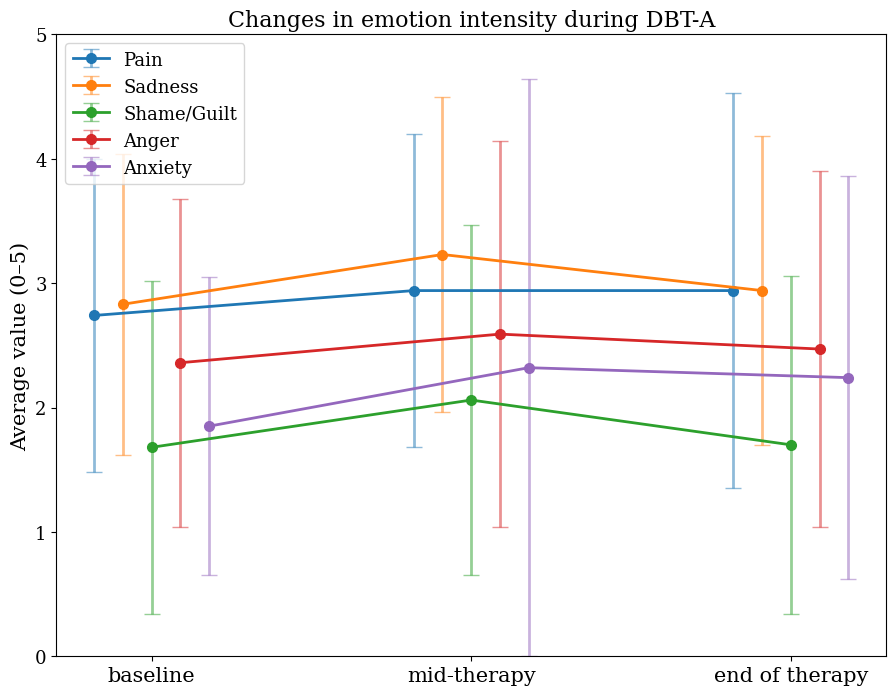

In [139]:
import numpy as np
import matplotlib.pyplot as plt

x_labels = ["baseline", "mid-therapy", "end of therapy"]
x = np.arange(len(x_labels))

data = {
    "Pain": (pain_int, pain_int_err),
    "Sadness": (sad, sad_err),
    "Shame/Guilt": (guilt, guilt_err),
    "Anger": (anger, anger_err),
    "Anxiety": (anxiety, anxiety_err),
}

colors = {
    "Pain": "#0072B2",
    "Sadness": "#56B4E9",
    "Shame/Guilt": "#CC79A7",
    "Anger": "#D55E00",
    "Anxiety": "#009E73",
}

offsets = np.linspace(-0.18, 0.18, len(data))

plt.figure(figsize=(9, 7))

for (label, (y, yerr)), dx in zip(data.items(), offsets):
    markers, caps, bars = plt.errorbar(
        x + dx, y, yerr=yerr,
        marker="o",
        capsize=6,
        linewidth=2,
        markersize=7,
#         color=colors[label],
        label=label
    )
    
    [bar.set_alpha(0.5) for bar in bars]
    [cap.set_alpha(0.5) for cap in caps]

plt.xticks(x, x_labels, fontsize=15)
plt.yticks(fontsize=13)

plt.ylabel("Average value (0–5)", fontsize=15)
plt.title("Changes in emotion intensity during DBT-A", fontsize=16)

plt.ylim(0, 5)
plt.legend(fontsize=13, frameon=True)
plt.tight_layout()

plt.savefig("changes_in_emotions.svg")
plt.savefig("changes_in_emotions.jpg", dpi=300)

plt.show()

In [128]:
marijuna = [9.14, 5.03, 7.55]
marijuna_err = [25.68, 12.07, 12.2]

alc = [15.74, 11.61, 22.42]
alc_err = [20.23, 19.57, 28.54]

meds = [71.24, 86.62,74.39]
meds_err = []


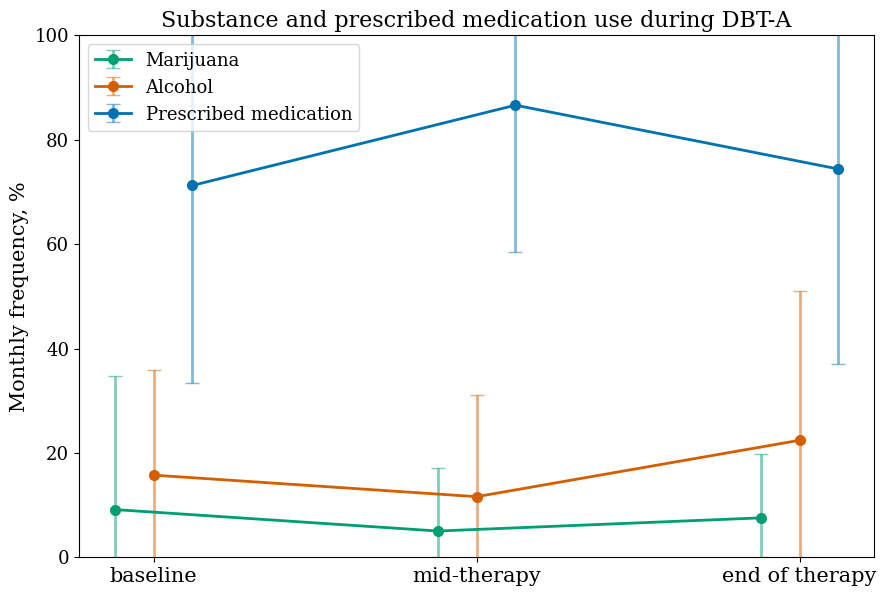

In [144]:
import numpy as np
import matplotlib.pyplot as plt

x_labels = ["baseline", "mid-therapy", "end of therapy"]
x = np.arange(len(x_labels))

marijuana = np.array([9.14, 5.03, 7.55])
marijuana_err = np.array([25.68, 12.07, 12.2])

alc = np.array([15.74, 11.61, 22.42])
alc_err = np.array([20.23, 19.57, 28.54])

meds = np.array([71.24, 86.62, 74.39])
meds_err = [37.81, 28.17, 37.27]  # add later, e.g. [10, 12, 9]

data = {
    "Marijuana": (marijuana, marijuana_err),
    "Alcohol": (alc, alc_err),
    "Prescribed medication": (meds, meds_err),
}

colors = {
    "Marijuana": "#009E73",  # green
    "Alcohol": "#D55E00",    # vermillion
    "Prescribed medication": "#0072B2", # blue
}

offsets = np.linspace(-0.12, 0.12, len(data))

plt.figure(figsize=(9, 6))

for (label, (y, yerr)), dx in zip(data.items(), offsets):
    yerr_plot = yerr if len(yerr) == len(y) else None

    marekers, caps, bars = plt.errorbar(
        x + dx, y,
        yerr=yerr_plot,
        marker="o",
        capsize=5,
        linewidth=2,
        markersize=7,
        color=colors[label],
        label=label
    )
    [bar.set_alpha(0.5) for bar in bars]
    [cap.set_alpha(0.5) for cap in caps]

plt.xticks(x, x_labels, fontsize=15)
plt.yticks(fontsize=13)

# plt.xlabel("Therapy stage", fontsize=15)
plt.ylabel("Monthly frequency, %", fontsize=15)
plt.title("Substance and prescribed medication use during DBT-A", fontsize=16)

plt.ylim(0, 100)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig("changes_in_substance.svg")
plt.savefig("changes_in_substance.jpg")
plt.show()

In [141]:
os.getcwd()

'/home/cbllover/HalfDome/SBI_analysis'